In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('data.csv')

In [3]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
data['diagnosis'].values

array(['M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M',
       'M', 'M', 'M', 'M', 'M', 'M', 'B', 'B', 'B', 'M', 'M', 'M', 'M',
       'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'B', 'M',
       'M', 'M', 'M', 'M', 'M', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'B',
       'B', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'M',
       'M', 'B', 'B', 'B', 'B', 'M', 'B', 'M', 'M', 'B', 'M', 'B', 'M',
       'M', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'M', 'M', 'B', 'B', 'B',
       'M', 'B', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'B', 'B',
       'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'M', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'M',
       'B', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'M', 'B', 'B', 'M', 'B',
       'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'M', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'B', 'B', 'M', 'M',
       'B', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'M

In [5]:
data['diagnosis'] = data['diagnosis'].map({'M':1,'B':0})
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [11]:
x = data.drop(['id','Unnamed: 32', 'diagnosis'], axis=1).values
x = x.reshape(-1, x.shape[1])
y = data['diagnosis'].values
y = y.reshape(-1,1)

In [14]:
from sklearn.model_selection import train_test_split
x_train, y_train, x_test, y_test = train_test_split(x, y, test_size=0.2, random_state=10)


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier


X = data.drop(['id', 'Unnamed: 32', 'diagnosis'], axis=1).values
y = data['diagnosis'].values


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)  
X_test = sc.transform(X_test)        


classifier = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
classifier.fit(X_train, y_train)


y_pred = classifier.predict(X_test)


C:\Users\AMIT\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\AMIT\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\ProgramData\miniconda3\Lib\subprocess.py", line 550, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\miniconda3\Lib\subprocess.py", line 1028, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\ProgramData\miniconda3\Lib\subprocess.py", line 1540, in _execute_child
 

In [19]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9473684210526315

In [3]:
data_2 = pd.read_csv('Social_Network_Ads.csv')
data_2.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
data_2.shape

(400, 5)

In [5]:
x = data_2.iloc[:, [2,3]].values

y =data_2.iloc[:,4].values 


In [8]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

sc = StandardScaler()
x_train = sc.fit_transform(x_train)  
x_test = sc.transform(x_test)        


In [9]:
from sklearn.svm import SVC
sv_classifier = SVC(kernel='linear', random_state=0)
sv_classifier.fit(x_train, y_train)

SVC(kernel='linear', random_state=0)

In [10]:
y_pred = sv_classifier.predict(x_test)

In [11]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8625

In [14]:
from sklearn.model_selection import GridSearchCV
parameters = [
    {'C': [1,10,100,3,5], 'kernel':['linear']},
    {'C': [1,30,10,7,5], 'kernel':['rbf'],
    'gamma': [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]}  
]

In [15]:
grid_search = GridSearchCV(estimator=sv_classifier, param_grid=parameters,
                           scoring='accuracy',
                           cv = 10,
                           n_jobs=-1)
grid_search = grid_search.fit(x_train, y_train)                        

In [17]:
pd.DataFrame(grid_search.cv_results_)[['mean_test_score', 'std_test_score', 'params']]

,mean_test_score,std_test_score,params
0,0.818750,0.057282,"{'C': 1, 'kernel': 'linear'}"
1,0.821875,0.065625,"{'C': 10, 'kernel': 'linear'}"
2,0.821875,0.065625,"{'C': 100, 'kernel': 'linear'}"
3,0.821875,0.065625,"{'C': 3, 'kernel': 'linear'}"
4,0.821875,0.065625,"{'C': 5, 'kernel': 'linear'}"
5,0.896875,0.052385,"{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}"
6,0.896875,0.048513,"{'C': 1, 'gamma': 0.2, 'kernel': 'rbf'}"
7,0.906250,0.050389,"{'C': 1, 'gamma': 0.3, 'kernel': 'rbf'}"
8,0.906250,0.055902,"{'C': 1, 'gamma': 0.4, 'kernel': 'rbf'}"
9,0.906250,0.046351,"{'C': 1, 'gamma': 0.5, 'kernel': 'rbf'}"


In [21]:
grid_search.cv_results_['params'][0]
grid_search.cv_results_['mean_test_score'][0]

0.81875

In [22]:
accuracy = grid_search.best_score_
print(accuracy)

0.9125


In [23]:
best_param = grid_search.best_params_
print(best_param)

{'C': 30, 'gamma': 0.2, 'kernel': 'rbf'}


In [24]:
grid_mean_scores = grid_search.cv_results_['mean_test_score']
print(grid_mean_scores)

[0.81875  0.821875 0.821875 0.821875 0.821875 0.896875 0.896875 0.90625
 0.90625  0.90625  0.909375 0.909375 0.90625  0.909375 0.903125 0.9125
 0.903125 0.90625  0.9      0.896875 0.89375  0.89375  0.896875 0.896875
 0.903125 0.9125   0.903125 0.9      0.9      0.9      0.89375  0.896875
 0.89375  0.903125 0.90625  0.90625  0.903125 0.9      0.903125 0.9
 0.896875 0.896875 0.903125 0.90625  0.9125   0.903125 0.896875 0.896875
 0.9      0.89375 ]


Text(0, 0.5, 'Cross validated Accuracy')

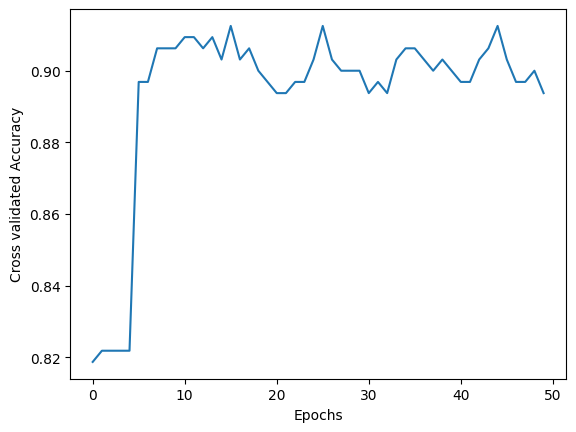

In [25]:
plt.plot(grid_mean_scores)
plt.xlabel("Epochs")
plt.ylabel("Cross validated Accuracy")